# Fase 1: Extração e Preparação do Grafo

Este notebook tem como objetivo realizar a extração dos dados viários utilizando a biblioteca `OSMnx` e preparar o grafo para análise.

In [1]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import folium
from shapely.geometry import Polygon

print(f"OSMnx version: {ox.__version__}")
print(f"NetworkX version: {nx.__version__}")

OSMnx version: 2.1.0
NetworkX version: 3.6.1


## Visualização da Área de Estudo

Antes de extrair os dados, vamos visualizar a área delimitada pelo polígono no mapa interativo.

In [2]:
# Coordenadas fornecidas (Latitude, Longitude)
coords = [
    (-5.918514, -35.277890),
    (-5.973278, -35.273041),
    (-5.973449, -35.188755),
    (-5.959791, -35.130390),
    (-5.874716, -35.167426),
    (-5.838087, -35.213432),
    (-5.883595, -35.265617)
]


# Criando o mapa centralizado na média das coordenadas
center_lat = sum(c[0] for c in coords) / len(coords)
center_lon = sum(c[1] for c in coords) / len(coords)
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="OpenStreetMap")

# Adicionando o polígono ao mapa
folium.Polygon(
    locations=coords,
    color="blue",
    weight=2,
    fill=True,
    fill_color="blue",
    fill_opacity=0.2,
    popup="Área de Estudo BR-101"
).add_to(m)

m

## Extração da Rede Viária

Agora que confirmamos a área, realizamos a extração do grafo utilizando o `OSMnx`.

In [3]:
# Invertendo para (Longitude, Latitude) para o Shapely/OSMnx
polygon_coords = [(lon, lat) for lat, lon in coords]
boundary_polygon = Polygon(polygon_coords)

# Extraindo o grafo da rede viária dentro do polígono
G = ox.graph_from_polygon(boundary_polygon, network_type="drive")

print(f"Grafo extraído com {len(G.nodes)} nós e {len(G.edges)} arestas.")

Grafo extraído com 8599 nós e 22131 arestas.


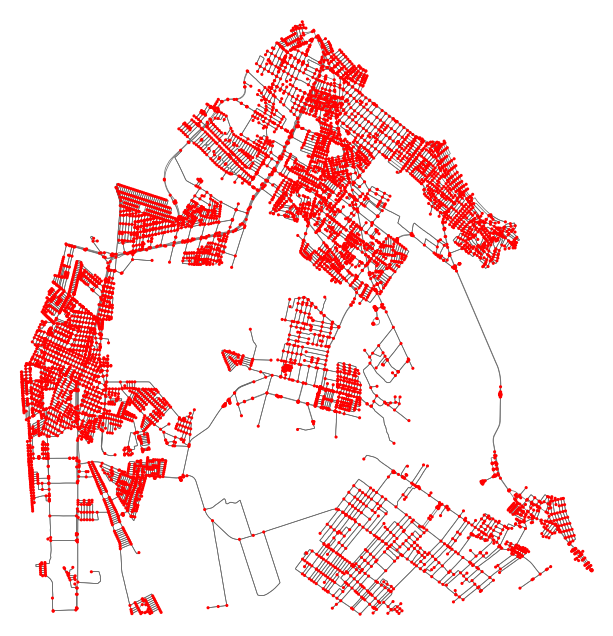

In [5]:
# Visualizando o grafo extraído de forma estática
fig, ax = ox.plot_graph(G, node_size=5, node_color="r", edge_color="#666666", edge_linewidth=0.5, bgcolor="w")
plt.show()

## Preparação do Grafo

Conforme o roteiro, precisamos converter o grafo para não-direcionado para permitir cálculos como o k-core.

In [6]:
# Convertendo para não-direcionado
G_undirected = G.to_undirected()
print(f"Grafo convertido para não-direcionado.")
print(f"Nós: {len(G_undirected.nodes)}, Arestas: {len(G_undirected.edges)}")

Grafo convertido para não-direcionado.
Nós: 8599, Arestas: 13066


# Fase 2: Análise Topológica

Nesta fase, calculamos as métricas de centralidade e a decomposição K-Core para identificar os nós mais importantes e as regiões mais densamente conectadas.

In [7]:
# 1. Grau (Degree)
degree_dict = dict(G_undirected.degree())
nx.set_node_attributes(G_undirected, degree_dict, 'degree')

print(f'Maior grau: {max(degree_dict.values())}')
print(f'Grau médio: {sum(degree_dict.values())/len(G_undirected):.2f}')

Maior grau: 5
Grau médio: 3.04


In [8]:
# 2. Centralidade de Intermediação (Betweenness Centrality)
# Esta métrica pode ser lenta. Para ~8.6k nós, pode levar alguns minutos.
print("Calculando Betweenness Centrality... (isso pode levar um momento)")
betweenness = nx.betweenness_centrality(G_undirected, normalized=True)
nx.set_node_attributes(G_undirected, betweenness, 'betweenness')

print('Centralidade de Intermediação calculada.')

Calculando Betweenness Centrality... (isso pode levar um momento)
Centralidade de Intermediação calculada.


In [9]:
# 3. Centralidade de Proximidade (Closeness Centrality)
print("Calculando Closeness Centrality...")
closeness = nx.closeness_centrality(G_undirected)
nx.set_node_attributes(G_undirected, closeness, 'closeness')

print('Centralidade de Proximidade calculada.')

Calculando Closeness Centrality...
Centralidade de Proximidade calculada.


In [10]:
# 4. Decomposição K-Core
# Primeiro removemos self-loops pois o core_number não os suporta
G_tmp = nx.Graph(G_undirected)
G_tmp.remove_edges_from(nx.selfloop_edges(G_tmp))

kcore = nx.core_number(G_tmp)
nx.set_node_attributes(G_undirected, kcore, 'kcore')

print(f'Maior K-Core encontrado: {max(kcore.values())}')

Maior K-Core encontrado: 2


## Exportação dos Dados

Salvamos o grafo processado com as métricas para visualização externa (ex: Gephi).

In [11]:
import networkx as nx

# 1. Cria uma cópia para preservar o grafo original intacto
G_to_save = G_undirected.copy()

# 2. Limpa os atributos das ARESTAS (edges)
for u, v, data in G_to_save.edges(data=True):
    for key, value in list(data.items()):
        # Se for geometria (Shapely), converte para WKT
        if key == "geometry" and hasattr(value, "wkt"):
            data[key] = value.wkt
        # Se for uma lista, transforma em string separada por vírgula (ex: ['A', 'B'] -> "A, B")
        elif isinstance(value, list):
            data[key] = ", ".join(map(str, value))

# 3. Limpa os atributos dos NÓS (nodes) - por segurança, caso haja listas lá também
for n, data in G_to_save.nodes(data=True):
    for key, value in list(data.items()):
        if key == "geometry" and hasattr(value, "wkt"):
            data[key] = value.wkt
        elif isinstance(value, list):
            data[key] = ", ".join(map(str, value))

# 4. Salva o arquivo limpo
nx.write_graphml(G_to_save, "data/br101_analise.graphml")
print("Grafo exportado com sucesso para data/br101_analise.graphml")

Grafo exportado com sucesso para data/br101_analise.graphml
